## 45 Days ML Journey - Day 08
### Polynomial Regression

In [1]:
# import necessary libs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# create synthetic dataset
total_datapoints = 100
X = 6 * np.random.rand(total_datapoints, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.rand(total_datapoints, 1)

Let's first see how our synthetic dataset looks like.
<br/>
For this we'll utilize the matplotlib lib. and plot the X and y on the 2D plane.

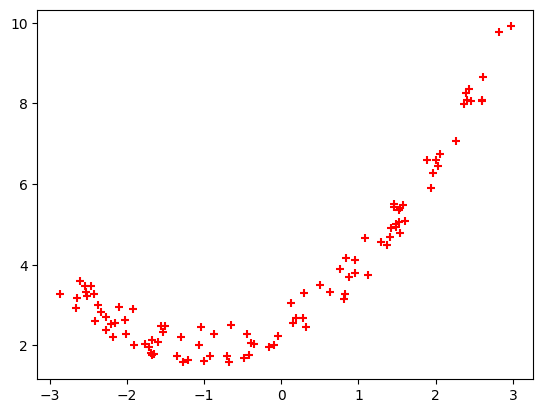

In [5]:
plt.scatter(X, y, color='red', marker='+')
plt.show()

As we can clearly see that, the above dataset is non-linear in nature, so first try to fit the simple `LinearRegression` and visualize how our prediction line looks like.
<br/>
For this we'll utilise the `LinearRegression` class of `sklearn` library.

In [8]:
simple_linear_regression = LinearRegression(n_jobs=-1)
simple_linear_regression.fit(X.reshape(-1, 1), y.reshape(-1, 1))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


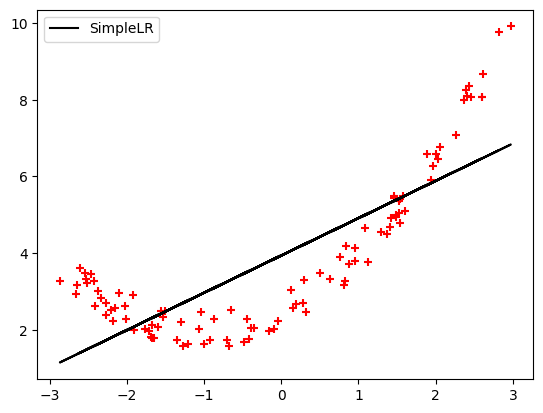

In [20]:
plt.scatter(X, y, color='red', marker='+')
plt.plot(X, simple_linear_regression.predict(X.reshape(-1,1)).reshape(-1, 1), color='black', label="SimpleLR")
plt.legend()
plt.show()

From the above figure, we can clearly see that the simple `LinearRegression` model did not perform well.
<br/>
Now, we try to fit the second degree polynomial features in our data and then visualize the performance of the model.

In [15]:
poly_degree2 = PolynomialFeatures(degree=2)
X_updated = poly_degree2.fit_transform(X.reshape(-1, 1))

In [17]:
polynomial_regression = LinearRegression(n_jobs=-1)
polynomial_regression.fit(X_updated, y.reshape(-1, 1))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


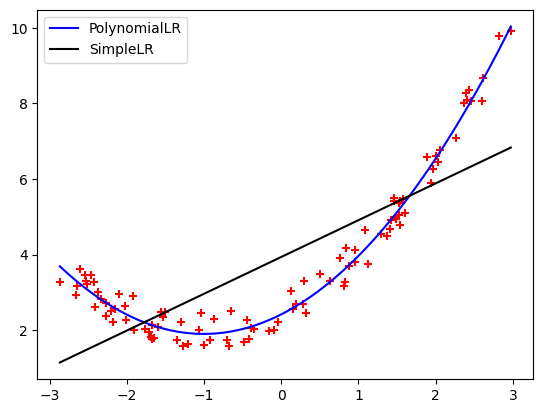

In [46]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly_degree2.transform(X_range)

plt.scatter(X, y, color='red', marker='+')
plt.plot(X_range, polynomial_regression.predict(X_range_poly), color='blue', label="PolynomialLR")
plt.plot(X_range, simple_linear_regression.predict(X_range), color='black', label="SimpleLR")

plt.legend()
plt.show()

### Evaluating performance

In [50]:
print("RMSE of Simple Linear Regression : ", (mean_squared_error(y, simple_linear_regression.predict(X.reshape(-1, 1)).reshape(-1,1) )**0.5))
print("RMSE of Polynomial Linear Regression : ", (mean_squared_error(
    y, polynomial_regression.predict(X_updated).reshape(-1, 1)
))**0.5)

RMSE of Simple Linear Regression :  1.2477099047772091
RMSE of Polynomial Linear Regression :  0.30855606929161405
